In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
# Load a sample dataset (MNIST for simplicity)
train_dir = "/content/drive/MyDrive/Week 5 - Introduction to CNN/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/Week 5 - Introduction to CNN/FruitinAmazon/test"

IMG_HEIGHT= 128
IMG_WIDTH= 128
BATCH_SIZE= 64
EPOCHS= 50
VAL_SPLIT= 0.2
SEED= 42

rescale = tf.keras.layers.Rescaling(1.0 / 255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
)
train_class_names = train_ds_raw.class_names
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds_raw.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
)
val_ds = val_ds_raw.map(lambda x, y: (rescale(x), y))

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED,
)
test_class_names = test_ds_raw.class_names
# Apply the normalization (Rescaling) to the validation dataset
test_ds = test_ds_raw.map(lambda x, y: (rescale(x), y))

NUM_CLASSES = len(test_class_names)

print(f"Train classes : {train_class_names}")
print(f"Test  classes : {test_class_names}")
print(f"Number of output classes: {NUM_CLASSES}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Train classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test  classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of output classes: 6


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64,  activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="Workshop5")

model.summary()

Model: "Workshop5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
callback = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",  # only saves best model, not every epoch
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1 # keeps the best model at the end
    ),
]

In [ ]:
# Train the model
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callback,
    verbose=1,
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.1693 - loss: 1.8322
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 794ms/step - accuracy: 0.1667 - loss: 1.8519 - val_accuracy: 0.0000e+00 - val_loss: 4.0585
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.1901 - loss: 1.9664
Epoch 2: val_accuracy improved from 0.00000 to 0.05556, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 595ms/step - accuracy: 0.2083 - loss: 1.9803 - val_accuracy: 0.0556 - val_loss: 2.2337
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.4705 - loss: 1.4962
Epoch 3: val_accuracy improved from 0.05556 to 0.11111, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 599ms/step - accuracy: 0.4722 - loss: 1.4946 - val_accuracy: 0.111

In [ ]:

true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

print("True Labels:")
print(true_labels)

True Labels:
[np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(1), np.int32(2), np.int32(2), np.int32(2), np.int32(2), np.int32(2), np.int32(3), np.int32(3), np.int32(3), np.int32(3), np.int32(3), np.int32(4), np.int32(4), np.int32(4), np.int32(4), np.int32(4), np.int32(5), np.int32(5), np.int32(5), np.int32(5), np.int32(5)]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions from the model on the test dataset
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Print Classification Report
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=test_class_names))

# Print Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(true_labels, predicted_labels))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
Classification Report:
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.40      0.40      0.40         5
    graviola       1.00      0.80      0.89         5
     guarana       0.43      0.60      0.50         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.33      0.60      0.43         5

    accuracy                           0.50        30
   macro avg       0.49      0.50      0.48        30
weighted avg       0.49      0.50      0.48        30

Confusion Matrix:
[[3 2 0 0 0 0]
 [0 2 0 0 0 3]
 [0 0 4 0 0 1]
 [0 0 0 3 1 1]
 [0 0 0 4 0 1]
 [1 1 0 0 0 3]]


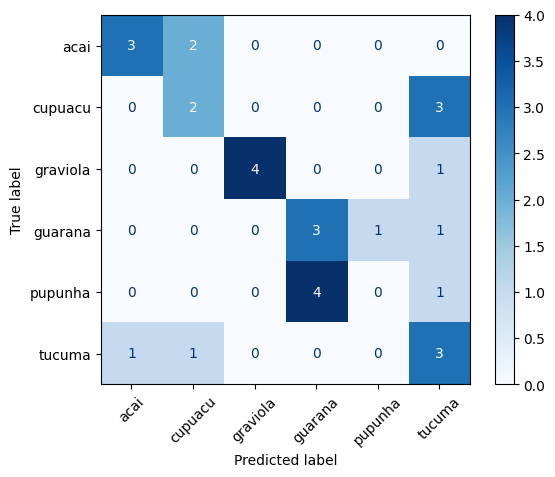

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predicted_labels,
    display_labels=test_class_names,
    cmap="Blues"
)
plt.xticks(rotation=45)
plt.show()

In [ ]:
model.save('Amazon_fruitin_connected_model.h5')